In [2]:
#TP4

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

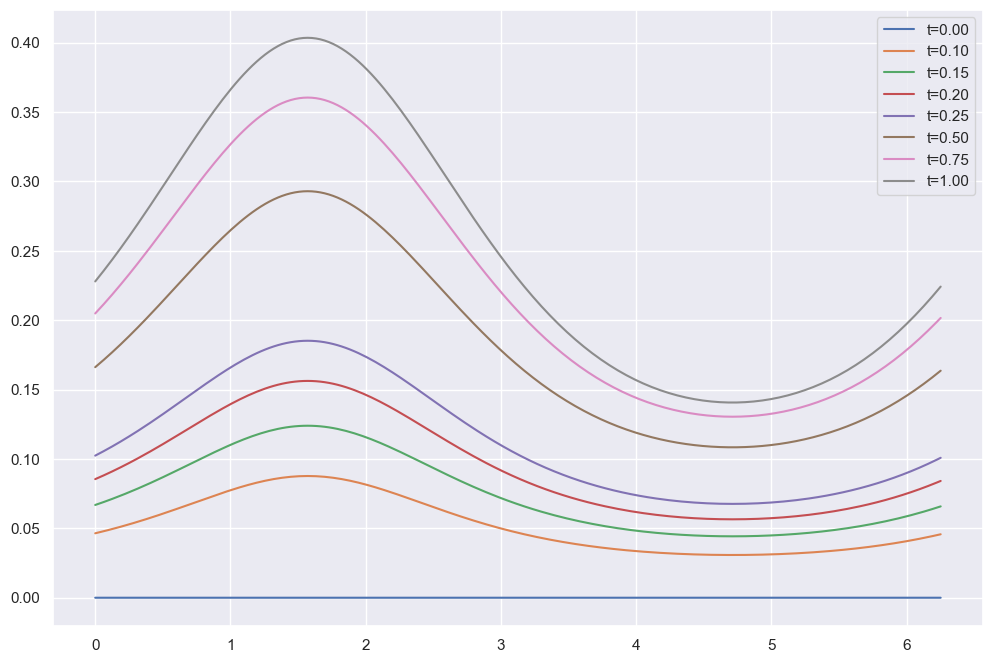

In [26]:
#Exercice 8:
#On veut résoudre le problème d'evolution: u_t - u_xx + u = -1/(2-sin(x))
#on prend de condition initiale la solution du problème 7 du TP3 (IC au dessus)
#on a periodicité en X, pas en T
#on note que du_k/dt = (1-k**2)*u_k - f_k, ou f_k sont les coefficients de f, et on trouve une EDO
#à résoudre pour chaque k: du_k/dt = -(1+k**2)*u_k - f_k, avec u_k(0) = IC[k]

#avec un calcul on trouve que la solution de l'edo est Ce^(At)+B,
#où A = -(1+k**2), B = f_k, et C = IC_k - f_k/(1+k**2)
#donc la solution est u_k(t) = (IC[k] - F[k]/(1+k**2))*np.exp(-(1+k**2)*t) + F[k]/(1+k**2)

def f(x):
    return -1/(2-np.sin(x))

T = np.linspace(0,1,200)
X = np.linspace(0,np.pi*2,200, endpoint=False)
N = 100
k = np.arange(-N+1,N+1)

F = np.fft.fft(f(X))/N
F = np.fft.fftshift(F)
IC = np.fft.fft(-f(X))/(N*(-1-k**2))
IC = np.fft.fftshift(IC)

Sol = [(IC + F/(1+k**2))*np.exp(-(1+k**2)*t) - F/(1+k**2) for t in T]

#Montrons la solution à différents instants de temps
fig, ax = plt.subplots(figsize=(12,8))
for i in [0, 20, 30, 40, 50, 100, 150, 199]:
    Sol[i] = np.fft.ifftshift(Sol[i])
    u = np.fft.ifft(Sol[i]*N)
    ax.plot(X,u,label=f"t={T[i]:.2f}")

ax.legend()
plt.show()





